In [ ]:
import cv2
import os
import shutil

import matplotlib.pyplot as plt


In [6]:
img_mask_path="C:\Projects Datasets\Brain Tumor Segmentation Dataset"

In [7]:
os.listdir(img_mask_path)

['image', 'mask']

In [12]:
image=os.path.join(img_mask_path,"image")
mask=os.path.join(img_mask_path,"mask")

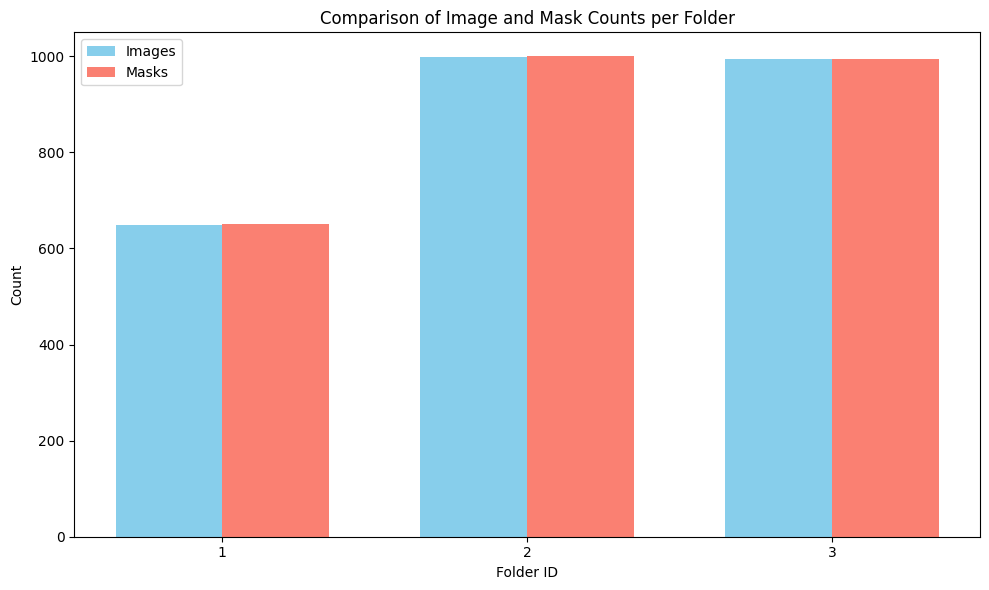

In [ ]:

base_img_path = os.path.join(img_mask_path, "image")
base_mask_path = os.path.join(img_mask_path, "mask")

folders = sorted([f for f in os.listdir(base_img_path) if os.path.isdir(os.path.join(base_img_path, f))])

folder_names = []
image_counts = []
mask_counts = []

for folder in folders:
    img_folder_path = os.path.join(base_img_path, folder)
    mask_folder_path = os.path.join(base_mask_path, folder)
    
    
    if os.path.exists(mask_folder_path):
        img_cnt = len([f for f in os.listdir(img_folder_path) if os.path.isfile(os.path.join(img_folder_path, f))])
        mask_cnt = len([f for f in os.listdir(mask_folder_path) if os.path.isfile(os.path.join(mask_folder_path, f))])
        
        folder_names.append(folder)
        image_counts.append(img_cnt)
        mask_counts.append(mask_cnt)

# Plotting
x = range(len(folder_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, image_counts, width, label='Images', color='skyblue')
ax.bar([i + width for i in x], mask_counts, width, label='Masks', color='salmon')

ax.set_xlabel('Folder ID')
ax.set_ylabel('Count')
ax.set_title('Comparison of Image and Mask Counts per Folder')
ax.set_xticks([i + width/2 for i in x])
ax.set_xticklabels(folder_names)
ax.legend()

plt.tight_layout()
plt.show()

#1- Glioma
#2- Meningioma
#3 - Pituitary

In [ ]:

src_root = img_mask_path
dst_root = "C:\Projects Datasets\Brain Tumor Segmentation Dataset\divided_data"

subfolders = ["1", "2","3"]
limit = 500

for folder in subfolders:
  
    img_src_dir = os.path.join(src_root, "image", folder)
    mask_src_dir = os.path.join(src_root, "mask", folder)
    
    img_dst_dir = os.path.join(dst_root, "image", folder)
    mask_dst_dir = os.path.join(dst_root, "mask", folder)

    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(mask_dst_dir, exist_ok=True)

    all_images = sorted(os.listdir(img_src_dir))
    subset = all_images[:limit]

    print(f"Processing Folder {folder}: Copying {len(subset)} pairs...")

    for filename in subset:
        name, ext = filename.rsplit(".", 1)    
        mask_src_file = os.path.join(mask_src_dir, f"{name}_m.{ext}")
 
        img_src_file = os.path.join(img_src_dir, filename)
        mask_src_file = os.path.join(mask_src_dir, f"{name}_m.{ext}")
        
        
        shutil.copy2(img_src_file, os.path.join(img_dst_dir, filename))
        
        
        if os.path.exists(mask_src_file):
            shutil.copy2(mask_src_file, os.path.join(mask_dst_dir, filename))
        else:
            print(f"Warning: Mask missing for {filename} in folder {folder}")

print("Done! Your subset is ready.")

Processing Folder 1: Copying 500 pairs...
Processing Folder 2: Copying 500 pairs...
Processing Folder 3: Copying 500 pairs...
Done! Your subset is ready.


In [47]:


# Using raw strings for Windows paths
src_root = r"C:\Projects Datasets\Brain Tumor Segmentation Dataset\divided_data"
dst_root = r"C:\Projects Datasets\Brain Tumor Segmentation Dataset\train_test_val"

subfolders = ["1", "2", "3"]

# Split counts per subfolder
train_limit = 300
val_limit = 100
test_limit = 100
total_per_folder = 500 

# Create the folder structure
for s in ['train', 'validation', 'test']:
    os.makedirs(os.path.join(dst_root, s, "image"), exist_ok=True)
    os.makedirs(os.path.join(dst_root, s, "mask"), exist_ok=True)

for folder in subfolders:
    img_src_dir = os.path.join(src_root, "image", folder)
    mask_src_dir = os.path.join(src_root, "mask", folder)
    
    # Sort to ensure we pick the same 500 every time
    all_images = sorted(os.listdir(img_src_dir))
    subset = all_images[:total_per_folder]
    
    print(f"Processing Subfolder {folder}...")

    for i, filename in enumerate(subset):
        # Determine split
        if i < train_limit:
            split = 'train'
        elif i < (train_limit + val_limit):
            split = 'validation'
        else:
            split = 'test'
            
        # Source paths
        img_src_file = os.path.join(img_src_dir, filename)
        
       
        mask_src_file = os.path.join(mask_src_dir, filename)
        
        # Destination paths (Keeping EXACT filename for image and mask)
        img_dst_file = os.path.join(dst_root, split, "image", filename)
        mask_dst_file = os.path.join(dst_root, split, "mask", filename)

        # Copy Image
        shutil.copy2(img_src_file, img_dst_file)
        
        # Copy Mask
        if os.path.exists(mask_src_file):
            shutil.copy2(mask_src_file, mask_dst_file)
        else:
            print(f"Warning: Mask {mask_src_file} not found for {filename}")

print("\nTransfer Complete.")

Processing Subfolder 1...
Processing Subfolder 2...
Processing Subfolder 3...

Transfer Complete.


In [49]:
import os
import shutil

src_root = r"C:\Projects Datasets\Segmentation_1\Segmentation"
dst_root = r"C:\Projects Datasets\Segmentation_1\Segmentation\train_test_val"

# Define your limits based on the total files
train_limit = 900
val_limit = 300
test_limit = 300
total_needed = train_limit + val_limit + test_limit # 1500 total

# Create the folder structure
for s in ['train', 'validation', 'test']:
    os.makedirs(os.path.join(dst_root, s, "image"), exist_ok=True)
    os.makedirs(os.path.join(dst_root, s, "mask"), exist_ok=True)

img_src_dir = os.path.join(src_root, "images")
mask_src_dir = os.path.join(src_root, "masks")

# Get and sort all images
all_images = sorted(os.listdir(img_src_dir))

# Take the first 1500 images
subset = all_images[:total_needed]

print(f"Total images found: {len(all_images)}")
print(f"Processing first {len(subset)} images...")

for i, filename in enumerate(subset):
    # Determine the split bucket based on index
    if i < train_limit:
        split = 'train'
    elif i < (train_limit + val_limit):
        split = 'validation'
    else:
        split = 'test'
        
    # Source paths
    img_src_file = os.path.join(img_src_dir, filename)
    mask_src_file = os.path.join(mask_src_dir, filename) # Matches exact filename
    
    # Destination paths
    img_dst_file = os.path.join(dst_root, split, "image", filename)
    mask_dst_file = os.path.join(dst_root, split, "mask", filename)

    # Copy Image
    shutil.copy2(img_src_file, img_dst_file)
    
    # Copy Mask
    if os.path.exists(mask_src_file):
        shutil.copy2(mask_src_file, mask_dst_file)
    else:
        print(f"Warning: Mask not found for {filename}")

print("\nTransfer Complete.")
print(f"Final Counts -> Train: {train_limit}, Val: {val_limit}, Test: {test_limit}")

Total images found: 3052
Processing first 1500 images...

Transfer Complete.
Final Counts -> Train: 900, Val: 300, Test: 300
